In [1]:
# Import the FEMSystem Class from directory above
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem
from RabiLondonSystem import RabiLondonSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from Units2D import Units2D

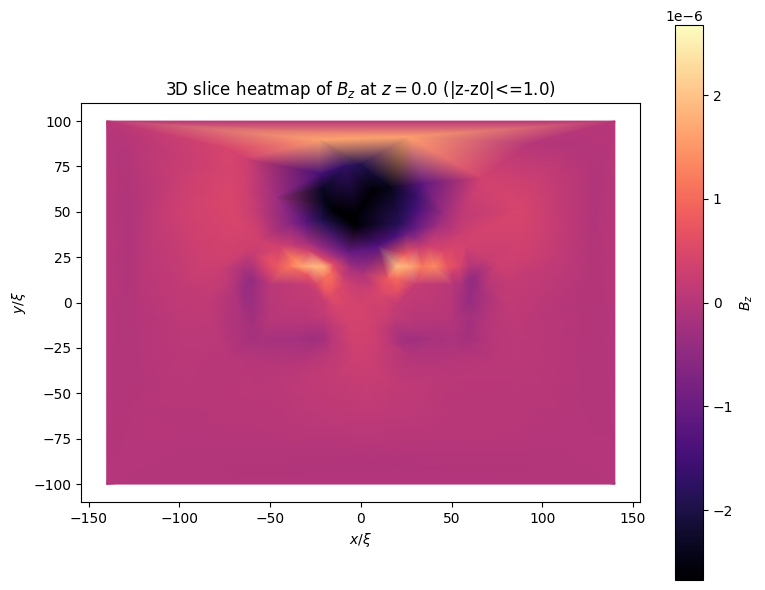

Source is: m = 0.1 | sigma: 50 | Coordinate: (0, 60, 0)


In [2]:
# import pickled object
class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        # Older checkpoints store RabiLondon2D as __main__.RabiLondon2D.
        # Remap to the current implementation class.
        if module == "__main__" and name == "RabiLondon2D":
            return RabiLondonSystem
        return super().find_class(module, name)


with open('3DRLcheckpoint10.pkl', 'rb') as f:
    pickle_obj = _CompatUnpickler(f).load()
    rabilondon = pickle_obj["rabilondon"]
    A_sol = pickle_obj["A_sol"]
    basis_edge = pickle_obj["basis_edge"]
    source_obj = pickle_obj["source_obj"]
    omega_d_rad_s = pickle_obj["omega_d_rad_s"]
    c_bar = pickle_obj["c_bar"]
    hamiltonian_time_data = pickle_obj["hamiltonian_time_data"]

# Visualize Solution
vis = VisualizeVF(rabilondon.mesh, basis_edge, A_sol)
vis.visualize_bz_slice_z0_3d(z0=0.0, tol=1.0, bz_symmetric_percentile=99.0, cmap="magma")

omega_d_nondim = rabilondon.omega_q

print(f"Source is: m = {source_obj['m']} | sigma: {source_obj['sigma']} | Coordinate: {source_obj['source_coord']}")

# Construct Rabi Hamiltonian

In [3]:
# Import A1 and A2 Matrices from pickle, and Pauli Decompose TLS Matrices
A1_mat, A2_mat = hamiltonian_time_data["A1_mat"], hamiltonian_time_data["A2_mat"]
A1_mat_TLS, A2_mat_TLS= rabilondon.TLS_matrix(A1_mat), rabilondon.TLS_matrix(A2_mat)
A1_mat_TLS_decomposed, A2_mat_TLS_decomposed = rabilondon.pauli_decompose(A1_mat_TLS), rabilondon.pauli_decompose(A2_mat_TLS)

print(f"A1I: {A1_mat_TLS_decomposed[0]} | A1X: {A1_mat_TLS_decomposed[1]} | A1Y: {A1_mat_TLS_decomposed[2]} | A1Z: {A1_mat_TLS_decomposed[3]}")
print(f"A2I: {A2_mat_TLS_decomposed[0]} | A2X: {A2_mat_TLS_decomposed[1]} | A2Y: {A2_mat_TLS_decomposed[2]} | A2Z: {A2_mat_TLS_decomposed[3]}")

a1_off_diag_max, a2_off_diag_max = np.max(np.abs(A1_mat_TLS - np.diag(np.diag(A1_mat_TLS)))), np.max(np.abs(A2_mat_TLS - np.diag(np.diag(A2_mat_TLS))))     
detuning_max = max(np.abs(A1_mat_TLS_decomposed[3]), np.abs(A2_mat_TLS_decomposed[3]))
a2z_detuning = np.real(A2_mat_TLS_decomposed[3])
print(f"A1 Off Diagonal Max: {a1_off_diag_max}")
print(f"A2 Off Diagonal Max: {a2_off_diag_max}\n")
print(f"Check that A1 off diagonal max is much much larger for Rabi Oscillations!! It is {a1_off_diag_max/a2_off_diag_max} times larger.")
print(f"Check that detuning is much lower too! Off diagonal of A1 is {a1_off_diag_max/a2z_detuning} times larger than the detuning (A1z and A2z).\n\n")

rabi_freq = np.sqrt(np.abs(A1_mat_TLS_decomposed[1])**2 + np.abs(A1_mat_TLS_decomposed[2])**2)  
rabi_period = float(2*np.pi/rabi_freq)
drive_period = float(2*np.pi/omega_d_nondim) # Remember Hamiltonian is nondimmed, so 1/energy or 1/time is nondimmed
print(f"Approx Rabi Frequency (Assuming x and y components of A2 are trivial): {rabi_freq}")
print(f"Rabi Period (nondim): {rabi_period} s")
print(f"Drive Period (nondim): {drive_period} s")
print(f"********* Ratio: {rabi_period/drive_period} *********\n\n")

print(f"Direct Detuning from A2Z Only (Since A2 has DC term): {a2z_detuning} | Fixing Drive Frequency by Adding Detuning")


# NEW DRIVE FREQUENCY ( + Detuning)
omega_d_nondim_new = (omega_d_nondim + 2*a2z_detuning)* (1 + 5.965e-8)
drive_period_new = float(2*np.pi/omega_d_nondim_new)

A1I: 0j | A1X: 0j | A1Y: (4.007905118896815e-13+0j) | A1Z: 0j
A2I: (1.6530975699424744e-08+0j) | A2X: (-1.6569856597925536e-11+0j) | A2Y: 0j | A2Z: 0j
A1 Off Diagonal Max: 4.0069954732741e-13
A2 Off Diagonal Max: 1.6562751170567935e-11

Check that A1 off diagonal max is much much larger for Rabi Oscillations!! It is 0.02419281378388405 times larger.
Check that detuning is much lower too! Off diagonal of A1 is inf times larger than the detuning (A1z and A2z).


Approx Rabi Frequency (Assuming x and y components of A2 are trivial): 4.007905118896815e-13
Rabi Period (nondim): 15676981903360.0 s
Drive Period (nondim): 475.8651285160956 s
********* Ratio: 32944170446.45822 *********


Direct Detuning from A2Z Only (Since A2 has DC term): 0.0 | Fixing Drive Frequency by Adding Detuning


*****************************************Using JAX/GPU for time evolution*****************************************




/scratch/gpfs/AROD/vc9839/finite-island-cqed/RabiLondon/RabiLondonSystem.py:788: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  to_backend = lambda x: jnp.asarray(x, dtype=jnp.complex128)
/scratch/gpfs/AROD/vc9839/finite-island-cqed/RabiLondon/RabiLondonSystem.py:801: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in eye is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  mat = jnp.eye(len(c0), dtype=jnp.complex128)
/scratch/gpfs/AROD/vc9839/finite-island-cqed/jax-gpu/lib64/python3.9/site-p

Time evolution:   0%|          | 0/399 [00:00<?, ?it/s]

/scratch/gpfs/AROD/vc9839/finite-island-cqed/RabiLondon/RabiLondonSystem.py:788: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  to_backend = lambda x: jnp.asarray(x, dtype=jnp.complex128)
/scratch/gpfs/AROD/vc9839/finite-island-cqed/RabiLondon/RabiLondonSystem.py:788: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  to_backend = lambda x: jnp.asarray(x, dtype=jnp.complex128)


[0.00000000e+00 5.87886777e+09 1.17577355e+10 ... 2.35037134e+13
 2.35095922e+13 2.35154711e+13] [0.00000000e+00 1.48702187e-08 3.92263871e-08 ... 1.65853739e-09
 7.48811246e-09 3.28590126e-08]
[[ 0.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j]
 [-4.71980919e-06-1.21852132e-04j  8.12083114e-01+5.83541773e-01j]
 [-7.66575491e-06-1.97908118e-04j  3.18957968e-01+9.47768841e-01j]
 ...
 [-1.57739683e-06-4.06945845e-05j -9.80826478e-01+1.94883088e-01j]
 [ 3.34826621e-06+8.64690787e-05j -9.10235048e-01-4.14091957e-01j]
 [ 7.01553790e-06+1.81134742e-04j -4.97546547e-01-8.67437261e-01j]]


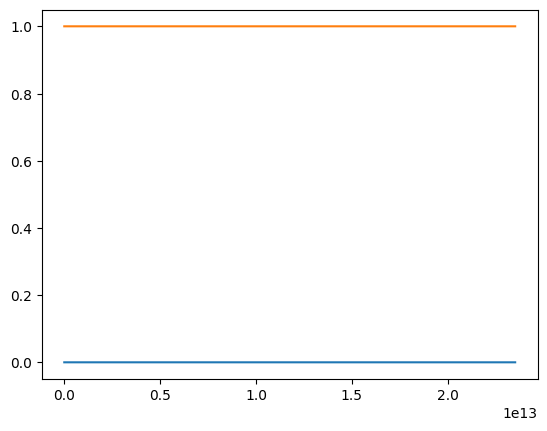

: 

In [ ]:
# Construct TLS Hamiltonian in Interaction Picture (rotated at DRIVE frequency, not typical H0)
H_tls_interaction = rabilondon.rabi_hamiltonian_tls_interaction_picture(basis_edge,A_sol,omega_d_nondim_new,A1_mat_TLS_decomposed,A2_mat_TLS_decomposed)

# Evolve for Rabi Oscillations
states, t_strob = rabilondon.rabi_efficient(H_tls_interaction,drive_period_new,400,rabi_period*1.5,4000)


# Plot
pop0, pop1 = np.abs(states[:, 0])**2, np.abs(states[:, 1])**2
plt.plot(t_strob, pop0)
plt.plot(t_strob, pop1)
print(t_strob,pop0)
print(states)

In [ ]:
# Raw LaTeX table for Pauli decomposition of A1 and A2
# Requires A1_mat_TLS_decomposed and A2_mat_TLS_decomposed from the previous cell.
import numpy as np

labels = [r"I", r"\\sigma_x", r"\\sigma_y", r"\\sigma_z"]
A1 = np.asarray(A1_mat_TLS_decomposed)
A2 = np.asarray(A2_mat_TLS_decomposed)

def fmt_complex(z):
    z = complex(z)
    # keep tiny numerical noise from cluttering output
    re = 0.0 if abs(z.real) < 1e-15 else z.real
    im = 0.0 if abs(z.imag) < 1e-15 else z.imag
    if im == 0.0:
        return f"{re:.6g}"
    if re == 0.0:
        return f"{im:.6g}i"
    sign = "+" if im >= 0 else "-"
    return f"{re:.6g} {sign} {abs(im):.6g}i"

latex_lines = []
latex_lines.append(r"\\begin{tabular}{c c c}")
latex_lines.append(r"\\hline")
latex_lines.append(r"Component & $A_1$ coefficient & $A_2$ coefficient ")
latex_lines.append(r"\\hline")

for i, lab in enumerate(labels):
    latex_lines.append(
        f"${lab}$ & ${fmt_complex(A1[i])}$ & ${fmt_complex(A2[i])}$ " + r"\\"
    )

latex_lines.append(r"\\hline")
latex_lines.append(r"\\end{tabular}")

raw_latex = "\n".join(latex_lines)
print(raw_latex)

\\begin{tabular}{c c c}
\\hline
Component & $A_1$ coefficient & $A_2$ coefficient 
\\hline
$I$ & $-1.86777e-06i$ & $0.0353546$ \\
$\\sigma_x$ & $7.82311e-07i$ & $7.38539e-07$ \\
$\\sigma_y$ & $2.0124e-05$ & $-9.31323e-10i$ \\
$\\sigma_z$ & $7.86968e-08i$ & $4.57764e-05$ \\
\\hline
\\end{tabular}


: 

In [154]:
# Eigenvectors are stored as columns; [:, 0] is the ground-state vector.
c0 = rabilondon.eigenvectors[:, 0]
print(f"Rabi Period: {rabi_period} | Drive Period: {drive_period}")

steps_per_drive_period = 5
dt = drive_period/steps_per_drive_period # Time steps on order of drive period (tehcnicallly only need Nyquist sampling rate of drive_period / 2, but 10 per period for safe measure)
end_time = rabi_period
t_grid = np.linspace(0, end_time, int(end_time/dt))   # dt = 0.1
output = rabilondon.evolve_piecewise_progress(c0, t_grid, H_of_t_new)
rabilondon.check_hermiticity_and_norm(H_of_t_new, t_grid, output)

Rabi Period: 312004.375 | Drive Period: 3.9457331609791195


Time evolution:   0%|          | 0/395368 [00:00<?, ?it/s]

Hermiticity:
  max ||H-H†||_F              = 0.000e+00
  max relative hermiticity err = 0.000e+00
  all times Hermitian (abs<1e-10)? True

Normalization of output:
  min sum|c|^2 = 0.999999999999999
  max sum|c|^2 = 1.000000000000001
  max |sum|c|^2 - 1| = 8.882e-16
  all times normalized (err<1e-10)? True

Finite-value checks:
  H contains only finite values? True
  output contains only finite values? True


{'herm_abs_err': array([0., 0., 0., ..., 0., 0., 0.]),
 'herm_rel_err': array([0., 0., 0., ..., 0., 0., 0.]),
 'probs': array([1., 1., 1., ..., 1., 1., 1.]),
 'norm_err': array([1.11022302e-16, 4.44089210e-16, 1.11022302e-16, ...,
        4.44089210e-16, 2.22044605e-16, 2.22044605e-16]),
 'bad_H_idx': array([], dtype=int64),
 'bad_norm_idx': array([], dtype=int64)}

## Generate the Figure

Fitted omega: 1.8821502e-05
Omega std err: 8.95e-13
RMSE: 1.22e-05
Fit parameters: A = 1.89e-09, tau = 3.31, C = 3e-05


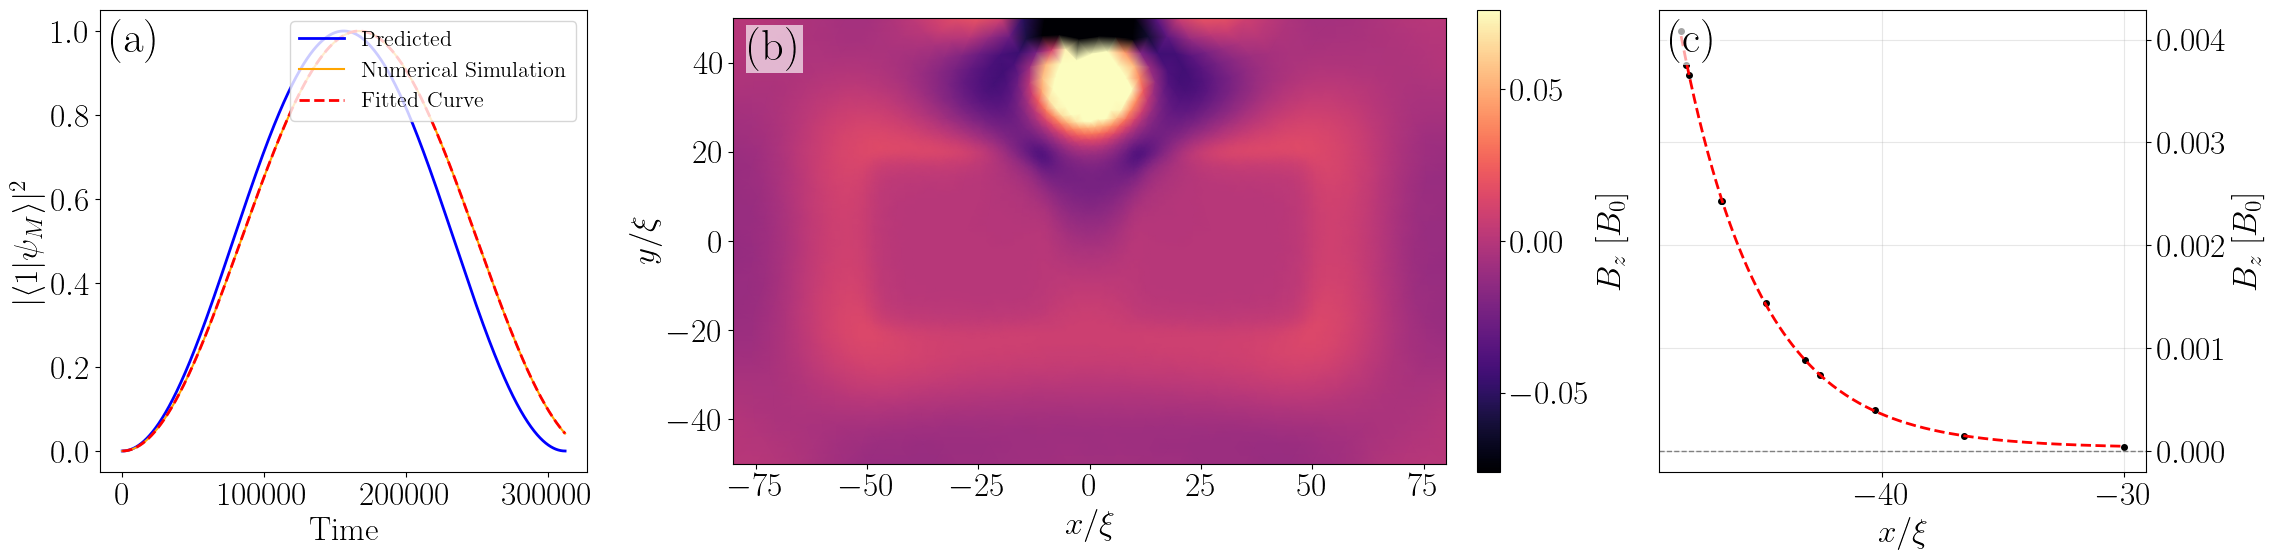

In [155]:
from scipy.optimize import curve_fit

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 24,
})

# Create three plots side-by-side with dynamic middle-column width
x_p1_tmp, y_p1_tmp, _ = vis._p1_plot_triangulation()
x_span = float(np.max(x_p1_tmp) - np.min(x_p1_tmp))
y_span = float(np.max(y_p1_tmp) - np.min(y_p1_tmp))

mid_ratio = (x_span / y_span) if y_span > 0 else 1.0
mid_ratio = float(np.clip(mid_ratio, 0.7, 2.0))  # optional stability clamp

fig = plt.figure(figsize=(22, 6), constrained_layout=False)
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, mid_ratio, 1.0], wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])


'''
Plot 1: Rabi Oscillations
'''
# Rabi Oscillations plot + fit state-1 population to (1 - cos(omega * t))/2
skip = 10
number_of_states = 5
eigenvalues, eigenvectors = rabilondon.eigenvalues, rabilondon.eigenvectors
populations = [[] for _ in range(number_of_states)]
for i in range(0, len(output), skip):
    psi = output[i]
    psi /= jnp.linalg.norm(psi)

    for j in range(number_of_states):
        p_j = jnp.abs(jnp.vdot(eigenvectors[:, j], psi))**2
        populations[j].append(p_j)

# Convert to arrays for fitting
sample_t = np.asarray(t_grid[::skip], dtype=float)
state1_pop = np.asarray(populations[1], dtype=float)


# (1 - cos(omega * t)) / 2
def rabi_model(t, omega):
    return 0.5 * (1.0 - np.cos(omega * t))

# Initial guess from your previously computed rabi_freq
omega0 = float(np.real(rabi_freq)) if np.ndim(rabi_freq) == 0 else float(np.real(rabi_freq[0]))

try:
    popt, pcov = curve_fit(rabi_model, sample_t, state1_pop, p0=[max(omega0, 1e-12)], bounds=(0.0, np.inf))
    omega_fit = float(popt[0])
    omega_fit_std = float(np.sqrt(np.diag(pcov))[0]) if np.isfinite(pcov).all() else np.nan
    fit_vals = rabi_model(sample_t, omega_fit)
    rmse = float(np.sqrt(np.mean((state1_pop - fit_vals) ** 2)))

    print(f"Fitted omega: {omega_fit:.9g}")
    print(f"Omega std err: {omega_fit_std:.3g}")
    print(f"RMSE: {rmse:.3g}")
except Exception as e:
    omega_fit = np.nan
    omega_fit_std = np.nan
    fit_vals = np.full_like(sample_t, np.nan)
    rmse = np.nan
    print("Fit failed:", e)

predicted_population = 0.5 * (1.0 - np.cos(float(np.real(rabi_freq)) * sample_t))

ax1.plot(sample_t, predicted_population, "-",color="blue", lw=2, label="Predicted") 
ax1.plot(sample_t, state1_pop, "-", color="orange",ms=3, label="Numerical Simulation")
if np.isfinite(omega_fit):
    ax1.plot(sample_t, fit_vals, "--", lw=2, color="red",label=f"Fitted Curve")

ax1.set_xlabel("Time")
ax1.set_ylabel(r"$|\langle 1 | \psi_M \rangle|^2$")
# ax1.set_title("Probability of Measuring State 1 vs Time")

ax1.legend(loc='upper right',fontsize=16)

'''
Plot 2: Meissner Screening
'''
vis.visualize_vf(A_sol, None, ax2, bz_symmetric_percentile=99.0)
# APS-style cleanup: keep frame, but remove extra internal padding around data.
x2, y2, _ = vis._p1_plot_triangulation()
ax2.set_xlim(np.min(x2), np.max(x2))
ax2.set_ylim(np.min(y2), np.max(y2))
ax2.margins(0)

'''
Plot 3: London Penetration Depth
'''

def london_penetration_fit(A_sol,ax,xmin=-20,xmax=-15,tol=1):
    # 1D cross-section of magnetic field Bz using ONLY mesh nodes at y = 0
    # Run this after the cell that computes A_sol and creates `vis`.
    B_nodes = np.asarray(vis._project_bz_to_nodes(A_sol)).ravel()
    x_p1, y_p1, _ = vis._p1_plot_triangulation()

    # Floating-point-safe selection of nodes exactly on y = 0
    mask = np.isclose(y_p1, 0.0, atol=tol)

    if not np.any(mask):
        raise ValueError(
            "No mesh nodes found at y=0. "
            "Try refining mesh or use a small |y| cutoff for an approximate section."
        )

    x_plot = np.asarray(x_p1[mask]).ravel()
    bz_plot = np.asarray(B_nodes[mask]).ravel()

    # Sort left-to-right for plotting
    order = np.argsort(x_plot)
    x_plot = x_plot[order]
    bz_plot = bz_plot[order]

    # Filter to only values where x in [-20, -12]
    mask_range = (x_plot >= xmin) & (x_plot <= xmax)
    x_plot = x_plot[mask_range]
    bz_plot = bz_plot[mask_range]

    from scipy.optimize import curve_fit

    # Define exponential decay model: A * exp(-x/tau) + C
    def exp_decay(x, A, tau, C):
        return A * np.exp(-x / tau) + C

    # Plot data and fit exponential decay

    # Initial guesses for parameters: amplitude, decay constant, offset
    A0 = bz_plot.max() - bz_plot.min()
    tau0 = (x_plot.max() - x_plot.min()) / 2
    C0 = bz_plot.min()

    try:
        popt, pcov = curve_fit(exp_decay, x_plot, bz_plot, p0=[A0, tau0, C0])
        A_opt, tau_opt, C_opt = popt
        print(f"Fit parameters: A = {A_opt:.3g}, tau = {tau_opt:.3g}, C = {C_opt:.3g}")
    except RuntimeError as e:
        print("Fit did not converge:", e)
        popt = None

    # Plot the data
    ax.plot(x_plot, bz_plot, "o", color="black", ms=4, lw=1.5) #, label=r"Data: $B_z$ at mesh nodes with $y=0$")
    ax.axhline(0.0, color="gray", linestyle="--", lw=1)

    # Plot the exponential decay fit, if available
    if popt is not None:
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 200)
        bz_fit = exp_decay(x_fit, *popt)
        ax.plot(x_fit, bz_fit, 'r--', lw=2, label=r"Exp. decay: $A e^{-x/\tau} + C$")

    ax.set_xlabel(r"$x/\xi$")
    ax.set_ylabel(r"$B_z$ $[B_0]$")
    # ax.set_title(r"1D Magnetic Field Cross-Section (Fit to Exponential Decay, $y=0$)")
    ax.grid(alpha=0.3)
    # ax.legend()

london_penetration_fit(A_sol,ax3,-49,-30,tol=2)

# Avoid collision with panel-2 colorbar text.
ax3.yaxis.set_label_position("right")
ax3.yaxis.tick_right()
ax3.tick_params(axis="y", pad=4)

# Panel labels
for ax, lab in zip([ax1, ax2, ax3], ["(a)", "(b)", "(c)"]):
    ax.text(
        0.02, 0.98, lab,
        transform=ax.transAxes,
        ha="left", va="top",
        fontweight="bold",
        fontsize=32,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.2),
    )

fig.subplots_adjust(left=0.05, right=0.98, bottom=0.18, top=0.95, wspace=0.12)

In [159]:
# Save to a pickle

import pickle

pickle_file_name = "rabilondonsaveorig.pkl"
pickled_obj = {
    "rabioutput": output,
    "t_grid": t_grid,
    "A_sol": A_sol,
    "rabilondon": rabilondon,
}

with open(pickle_file_name, 'wb') as f:
    pickle.dump(pickled_obj, f)

# Older Code

Fitted omega: 1.8821502e-05
Omega std err: 8.95e-13
RMSE: 1.22e-05


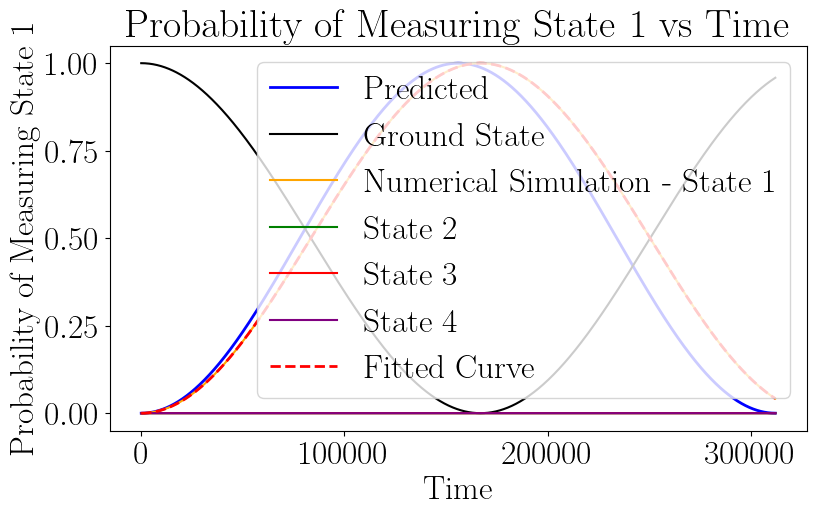

In [156]:
from scipy.optimize import curve_fit
# Generate the Figure



# Rabi Oscillations plot + fit state-1 population to (1 - cos(omega * t))/2

skip = 10
number_of_states = 5
eigenvalues, eigenvectors = rabilondon.eigenvalues, rabilondon.eigenvectors
populations = [[] for _ in range(number_of_states)]
for i in range(0, len(output), skip):
    psi = output[i]
    psi /= jnp.linalg.norm(psi)

    for j in range(number_of_states):
        p_j = jnp.abs(jnp.vdot(eigenvectors[:, j], psi))**2
        populations[j].append(p_j)

# Convert to arrays for fitting
sample_t = np.asarray(t_grid[::skip], dtype=float)
ground_pop = np.asarray(populations[0], dtype=float)
state1_pop = np.asarray(populations[1], dtype=float)
state2_pop = np.asarray(populations[2], dtype=float)
state3_pop = np.asarray(populations[3], dtype=float)
state4_pop = np.asarray(populations[4], dtype=float)

# Model requested: (1 - cos(omega * t)) / 2
def rabi_model(t, omega):
    return 0.5 * (1.0 - np.cos(omega * t))

# Initial guess from your previously computed rabi_freq
omega0 = float(np.real(rabi_freq)) if np.ndim(rabi_freq) == 0 else float(np.real(rabi_freq[0]))

try:
    popt, pcov = curve_fit(rabi_model, sample_t, state1_pop, p0=[max(omega0, 1e-12)], bounds=(0.0, np.inf))
    omega_fit = float(popt[0])
    omega_fit_std = float(np.sqrt(np.diag(pcov))[0]) if np.isfinite(pcov).all() else np.nan
    fit_vals = rabi_model(sample_t, omega_fit)
    rmse = float(np.sqrt(np.mean((state1_pop - fit_vals) ** 2)))

    print(f"Fitted omega: {omega_fit:.9g}")
    print(f"Omega std err: {omega_fit_std:.3g}")
    print(f"RMSE: {rmse:.3g}")
except Exception as e:
    omega_fit = np.nan
    omega_fit_std = np.nan
    fit_vals = np.full_like(sample_t, np.nan)
    rmse = np.nan
    print("Fit failed:", e)

predicted_population = 0.5 * (1.0 - np.cos(float(np.real(rabi_freq)) * sample_t))

plt.figure(figsize=(9, 5))
plt.plot(sample_t, predicted_population, "-",color="blue", lw=2, label="Predicted")
plt.plot(sample_t, ground_pop, "-", color="black",ms=3, label="Ground State")
plt.plot(sample_t, state1_pop, "-", color="orange",ms=3, label="Numerical Simulation - State 1")
plt.plot(sample_t, state2_pop, "-", color="green",ms=3, label="State 2")
plt.plot(sample_t, state3_pop, "-", color="red",ms=3, label="State 3")
plt.plot(sample_t, state4_pop, "-", color="purple",ms=3, label="State 4")
if np.isfinite(omega_fit):
    plt.plot(sample_t, fit_vals, "--", lw=2, color="red",label=f"Fitted Curve")

plt.xlabel("Time")
plt.ylabel("Probability of Measuring State 1")
plt.title("Probability of Measuring State 1 vs Time")

plt.legend(loc='upper right')


Fit parameters: A = -1.41e-06, tau = 5.22, C = -0.000887


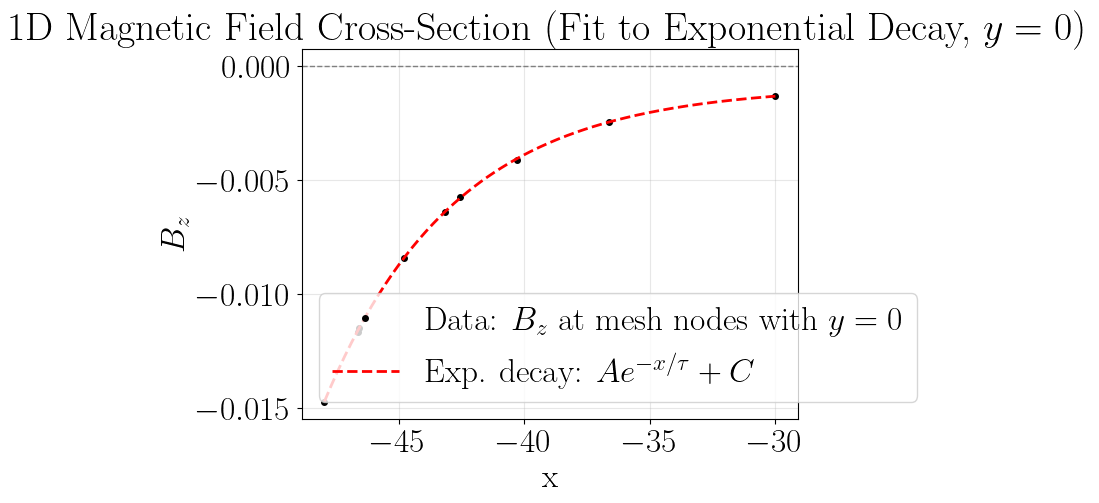

In [88]:
def london_penetration_fit(A_sol,ax,xmin=-20,xmax=-15,tol=1):
    # 1D cross-section of magnetic field Bz using ONLY mesh nodes at y = 0
    # Run this after the cell that computes A_sol and creates `vis`.
    B_nodes = np.asarray(vis._project_bz_to_nodes(A_sol)).ravel()
    x_p1, y_p1, _ = vis._p1_plot_triangulation()

    # Floating-point-safe selection of nodes exactly on y = 0
    mask = np.isclose(y_p1, 0.0, atol=tol)

    if not np.any(mask):
        raise ValueError(
            "No mesh nodes found at y=0. "
            "Try refining mesh or use a small |y| cutoff for an approximate section."
        )

    x_plot = np.asarray(x_p1[mask]).ravel()
    bz_plot = np.asarray(B_nodes[mask]).ravel()

    # Sort left-to-right for plotting
    order = np.argsort(x_plot)
    x_plot = x_plot[order]
    bz_plot = bz_plot[order]

    # Filter to only values where x in [-20, -12]
    mask_range = (x_plot >= xmin) & (x_plot <= xmax)
    x_plot = x_plot[mask_range]
    bz_plot = bz_plot[mask_range]

    from scipy.optimize import curve_fit

    # Define exponential decay model: A * exp(-x/tau) + C
    def exp_decay(x, A, tau, C):
        return A * np.exp(-x / tau) + C

    # Plot data and fit exponential decay

    # Initial guesses for parameters: amplitude, decay constant, offset
    A0 = bz_plot.max() - bz_plot.min()
    tau0 = (x_plot.max() - x_plot.min()) *10
    C0 = bz_plot.min()

    try:
        popt, pcov = curve_fit(exp_decay, x_plot, bz_plot, p0=[A0, tau0, C0])
        A_opt, tau_opt, C_opt = popt
        print(f"Fit parameters: A = {A_opt:.3g}, tau = {tau_opt:.3g}, C = {C_opt:.3g}")
    except RuntimeError as e:
        print("Fit did not converge:", e)
        popt = None

    # Plot the data
    ax.plot(x_plot, bz_plot, "o", color="black", ms=4, lw=1.5, label=r"Data: $B_z$ at mesh nodes with $y=0$")
    ax.axhline(0.0, color="gray", linestyle="--", lw=1)

    # Plot the exponential decay fit, if available
    if popt is not None:
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 200)
        bz_fit = exp_decay(x_fit, *popt)
        ax.plot(x_fit, bz_fit, 'r--', lw=2, label=r"Exp. decay: $A e^{-x/\tau} + C$")

    ax.set_xlabel("x")
    ax.set_ylabel(r"$B_z$")
    ax.set_title(r"1D Magnetic Field Cross-Section (Fit to Exponential Decay, $y=0$)")
    ax.grid(alpha=0.3)
    ax.legend()

fig,ax = plt.subplots()
london_penetration_fit(A_sol,ax,-48,-30,tol=2)